   profile pic  nums/length username  fullname words  nums/length fullname  \
0            1                  0.27               0                   0.0   
1            1                  0.00               2                   0.0   
2            1                  0.10               2                   0.0   
3            1                  0.00               1                   0.0   
4            1                  0.00               2                   0.0   

   name==username  description length  external URL  private  #posts  \
0               0                  53             0        0      32   
1               0                  44             0        0     286   
2               0                   0             0        1      13   
3               0                  82             0        0     679   
4               0                   0             0        1       6   

   #followers  #follows  fake  
0        1000       955     0  
1        2740       533     0  
2 

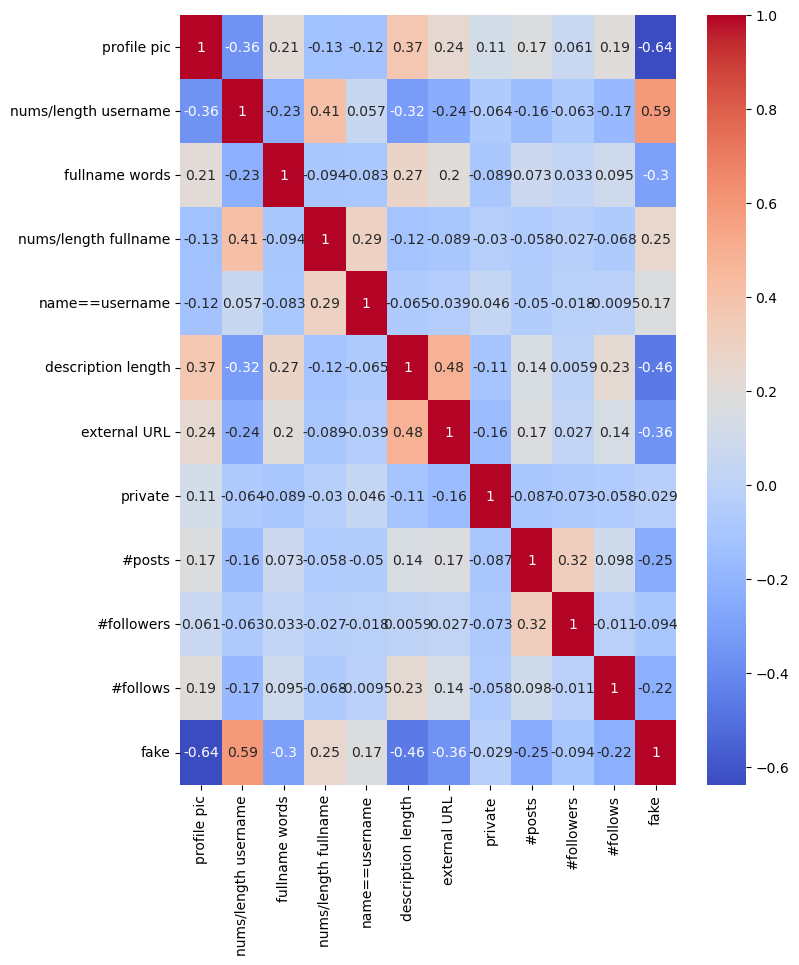

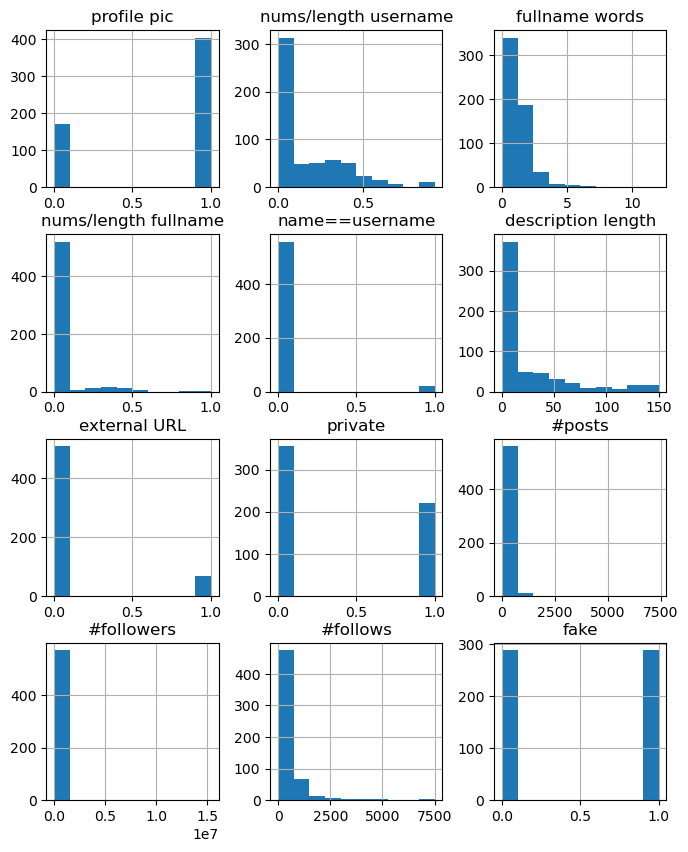

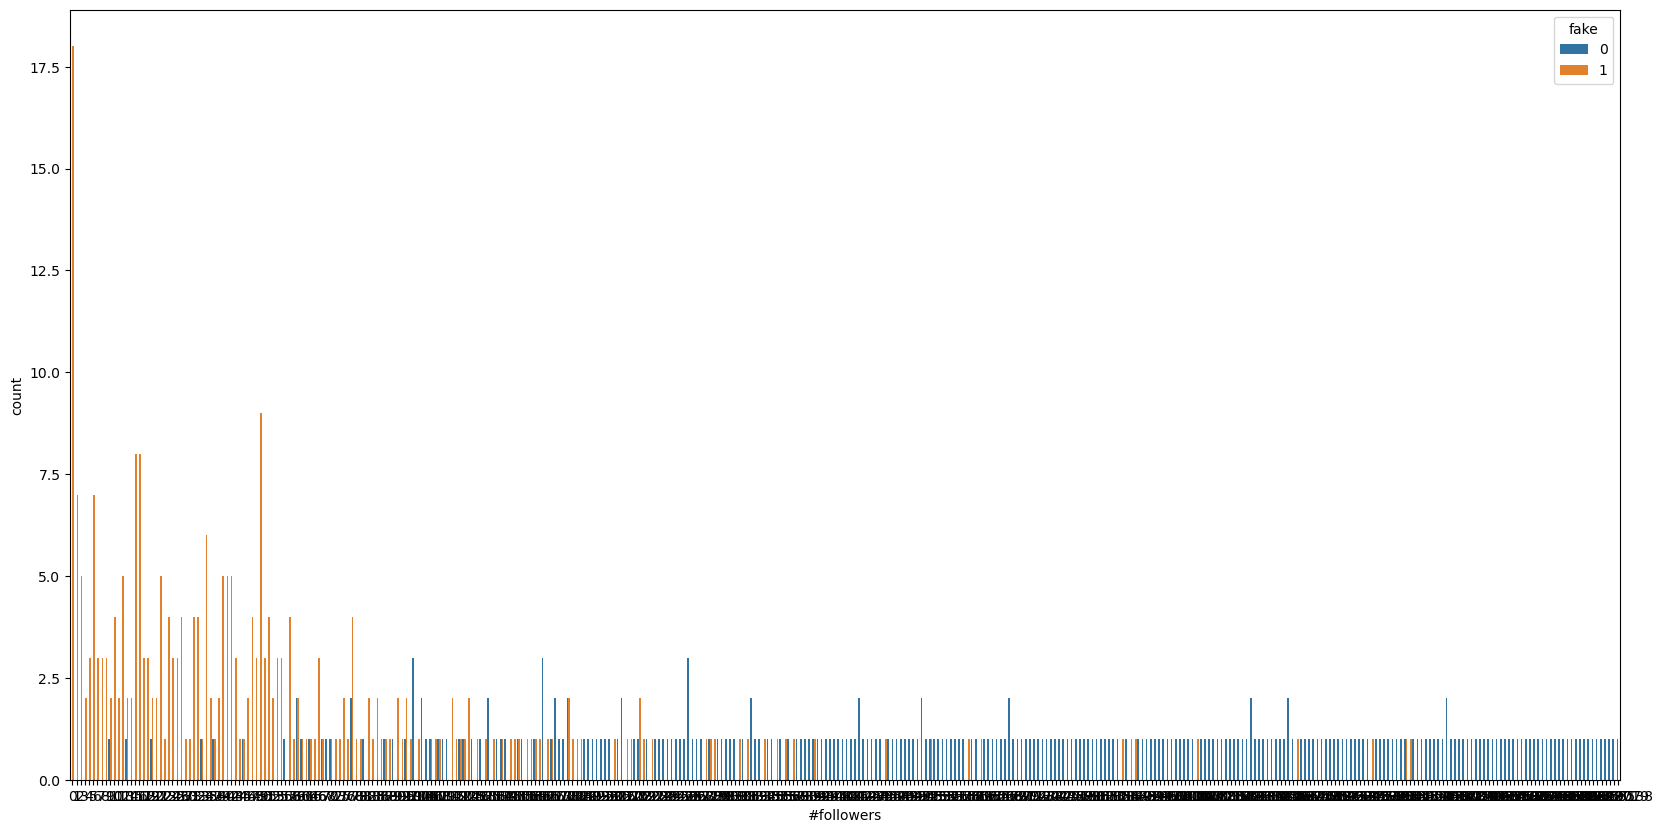

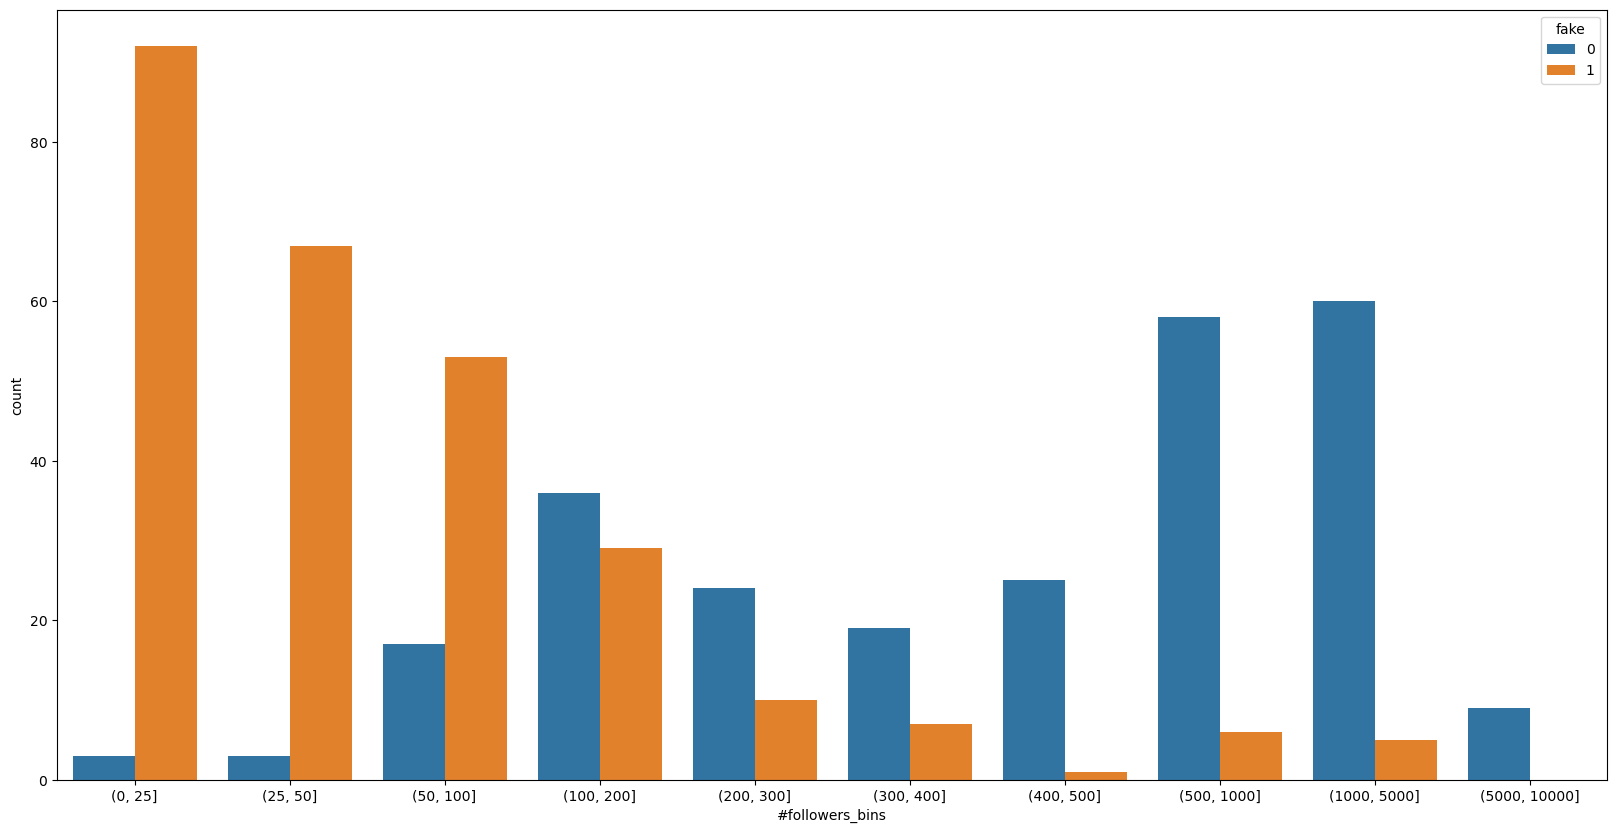

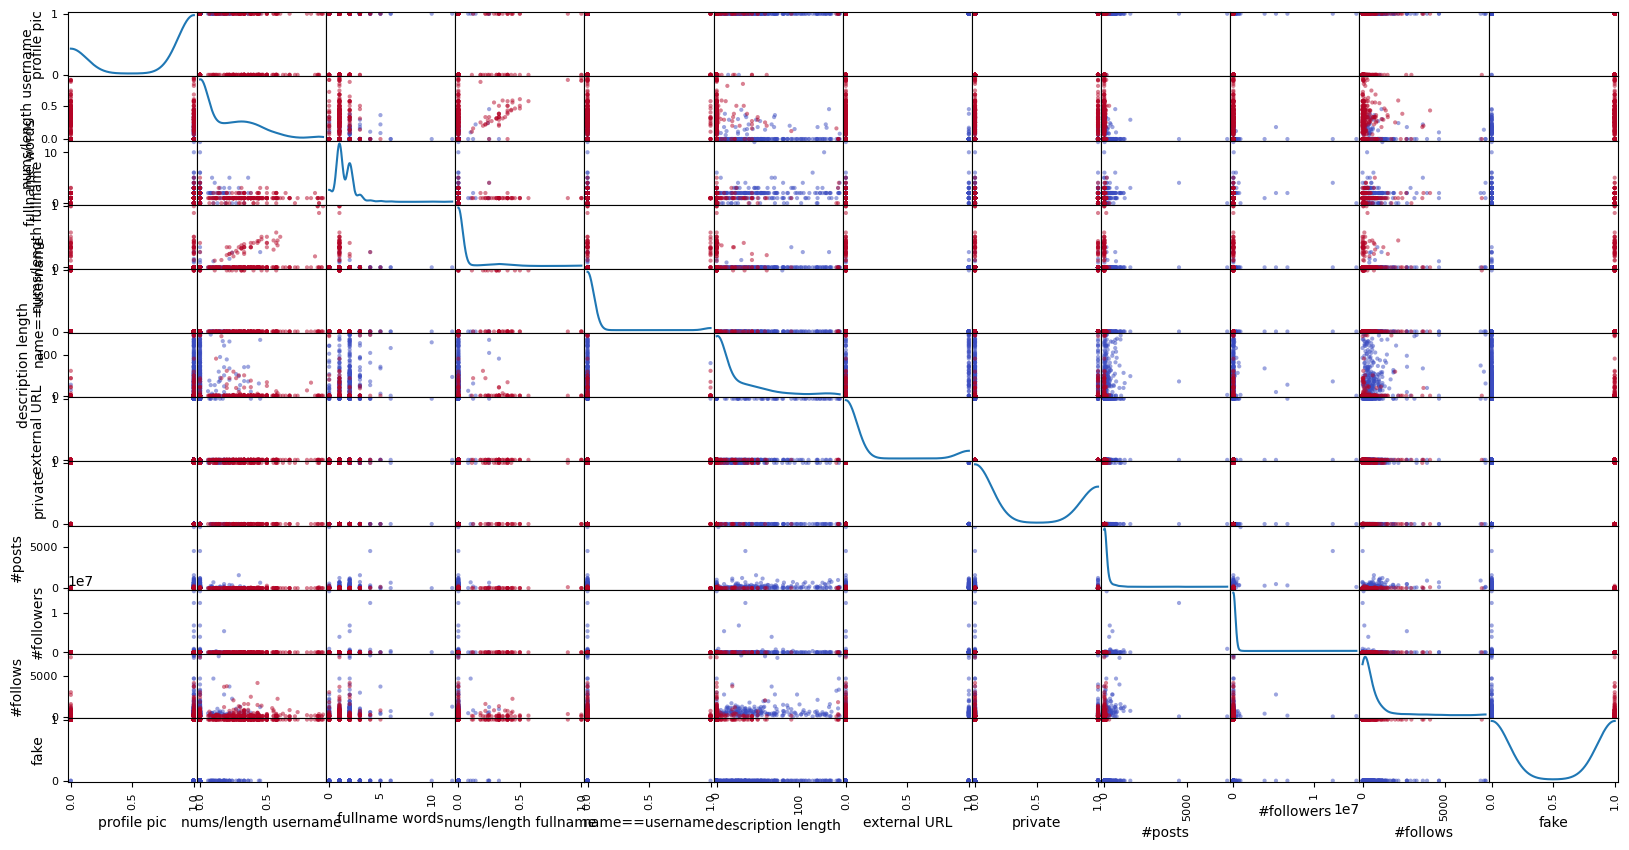

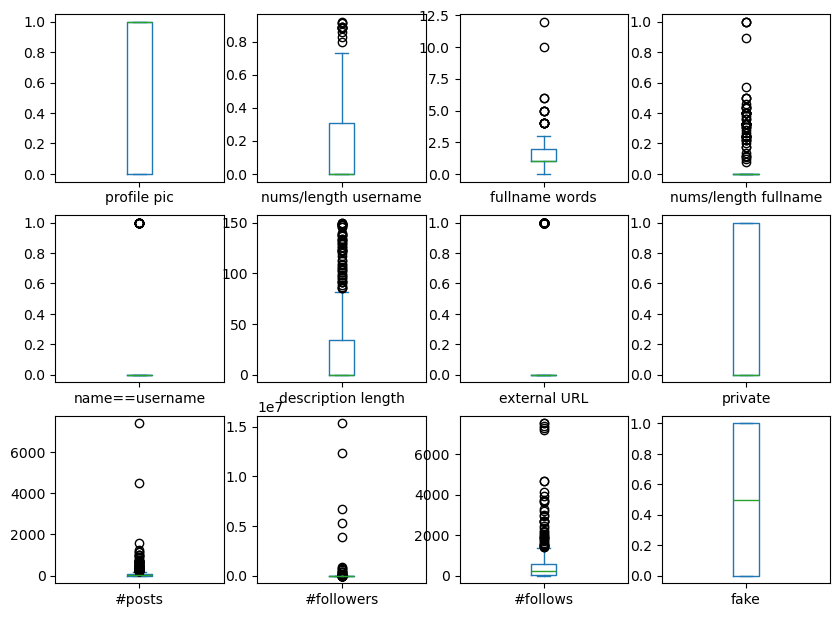

profile pic               int64
nums/length username    float64
fullname words            int64
nums/length fullname    float64
name==username            int64
description length        int64
external URL              int64
private                   int64
#posts                    int64
#followers                int64
#follows                  int64
dtype: object
int64
              precision    recall  f1-score   support

           0       0.85      0.90      0.88        63
           1       0.88      0.81      0.84        53

    accuracy                           0.86       116
   macro avg       0.86      0.86      0.86       116
weighted avg       0.86      0.86      0.86       116



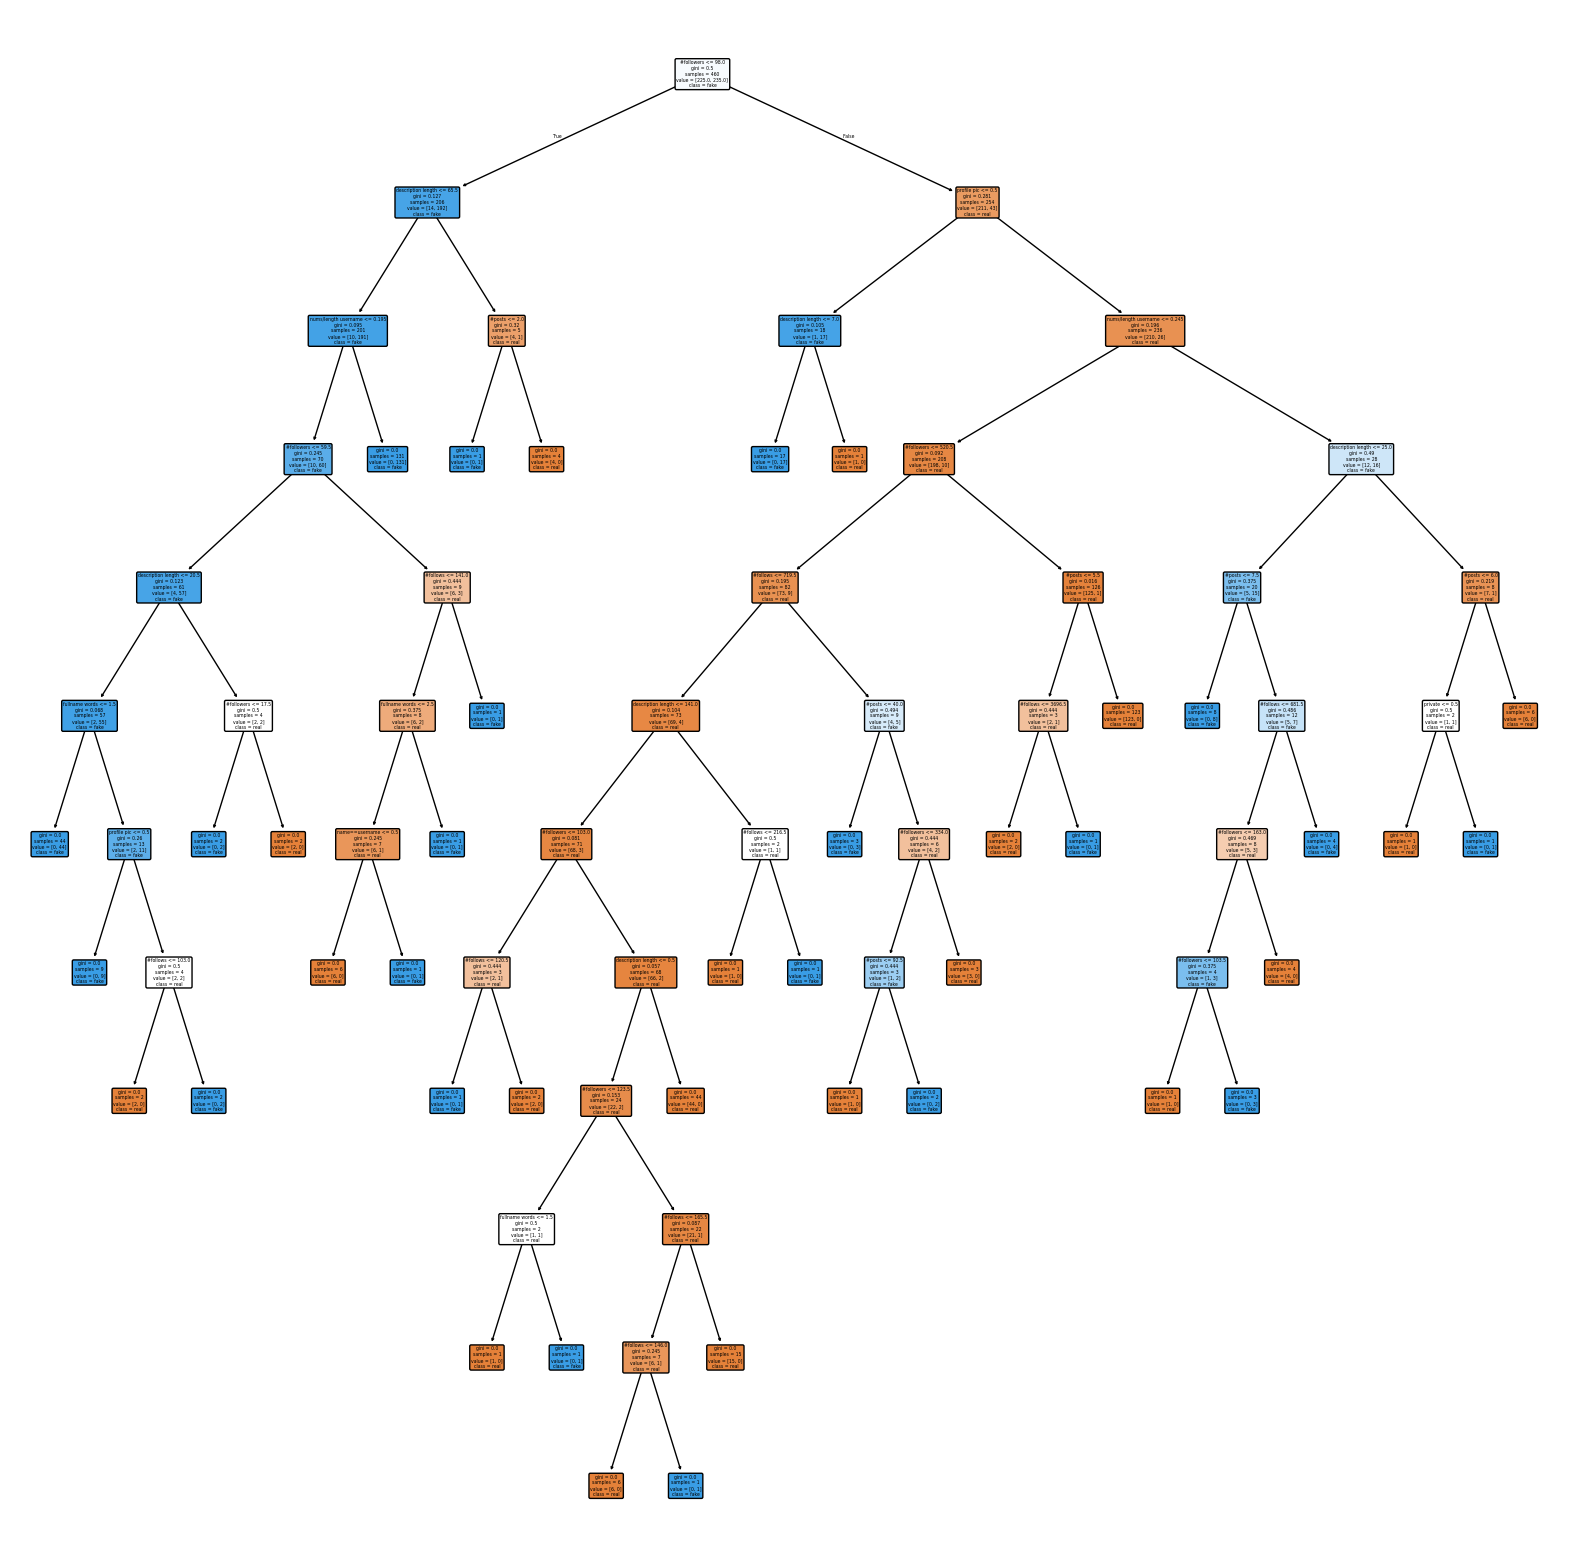

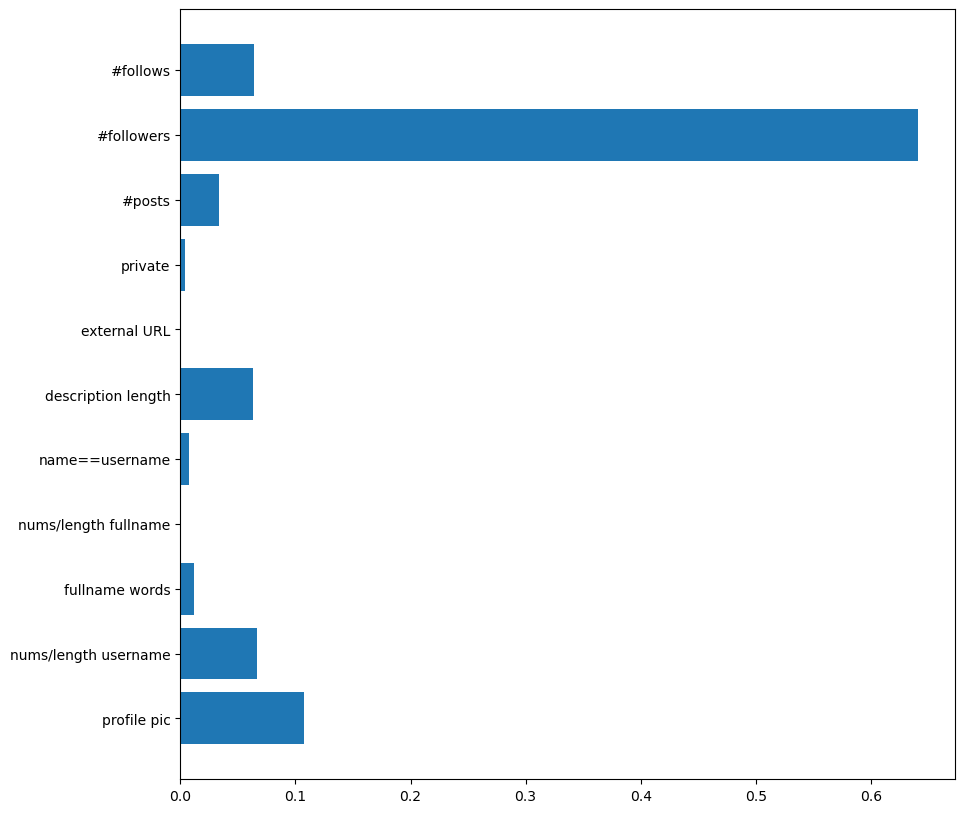

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       288
           1       0.98      0.97      0.97       288

    accuracy                           0.97       576
   macro avg       0.97      0.97      0.97       576
weighted avg       0.97      0.97      0.97       576



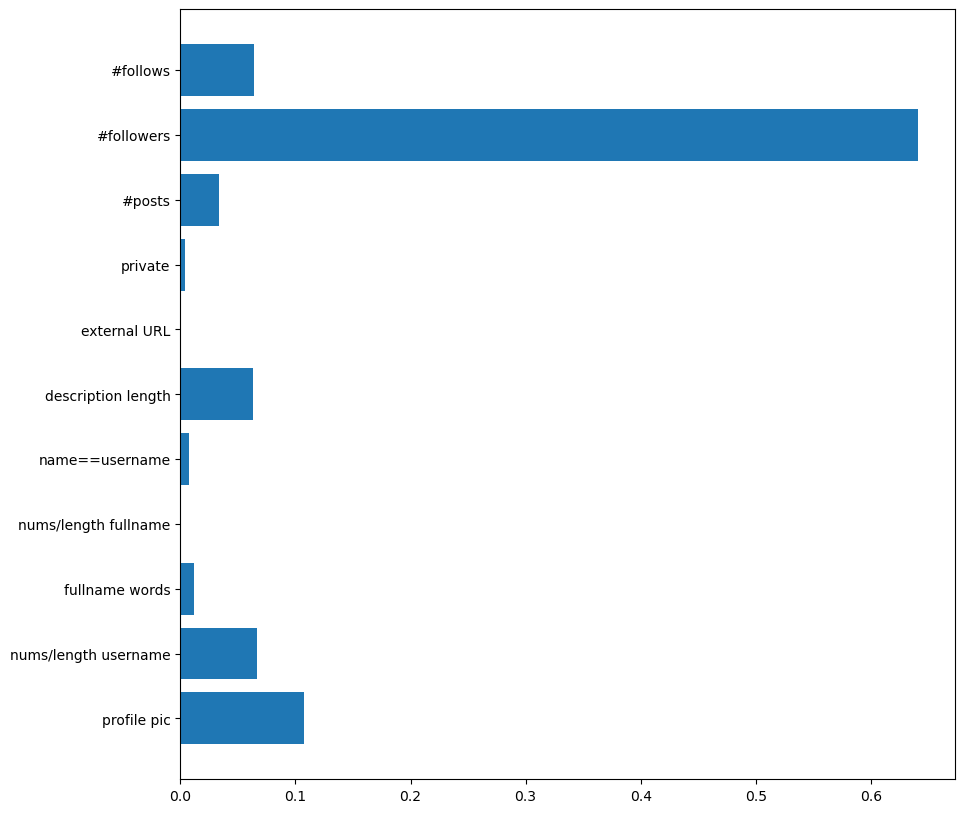

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('C:/Users/HP/Documents/DA_projects/Insta/train.csv')
# Intial data check
print(df.head())
print(df.isnull().sum())
print("\nColumns:",df.columns.tolist())
print(df.describe())
plt.figure(figsize=(8,10))
sns.heatmap(df.corr(), annot=True,cmap='coolwarm')
plt.show()
df.hist(figsize=(8,10))
plt.show()
plt.figure(figsize=(20,10))
sns.countplot(data=df, x='#followers',hue='fake')
plt.show()
# create bins for #followers column
bins=[0,25,50,100,200,300,400,500,1000,5000,10000]
df['#followers_bins']=pd.cut(df['#followers'],bins=bins)
plt.figure(figsize=(20,10))
sns.countplot(x='#followers_bins',hue='fake',data=df)
plt.show()
from pandas.plotting import scatter_matrix
scatter_matrix(df, figsize=(20,10), diagonal = 'kde', c=df['fake'], cmap='coolwarm')
plt.show()
df.plot(kind='box', subplots=True, layout=(4,4), figsize=(10,10))
plt.show()
x = df.drop(['#followers_bins', 'fake'], axis=1)
y = df['fake']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = DecisionTreeClassifier()
print(x_train.dtypes)
print(y_train.dtypes)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred)
confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
# Explain model with tree plot
from sklearn import tree
plt.figure(figsize=(20,20))
tree.plot_tree(model, filled=True, feature_names=x.columns, class_names=['real','fake'], rounded=True)
plt.show()
model.feature_importances_

plt.figure(figsize=(10,10))
plt.barh(x.columns, model.feature_importances_)
plt.show()
df=pd.read_csv('C:/Users/HP/Documents/DA_projects/Insta/train.csv')
df.head()

x_test=df.drop('fake',axis=1)
y_pred=model.predict(x_test)
y_pred
accuracy_score(df['fake'],y_pred)
print(classification_report(df['fake'], y_pred))
plt.figure(figsize=(10,10))
plt.barh(x_test.columns, model.feature_importances_)
plt.show()